In [ ]:
# import cell
import os
import re
import warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
from collections.abc import Sequence
import glob

from scipy import stats
from scipy.stats import mannwhitneyu, ks_2samp, ttest_ind
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from skimage.measure import label as sk_label, regionprops
from skimage.color import rgb2lab
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedGroupKFold, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, f1_score

### extract lesion feature

In [44]:
def extract_lesion_feature_shape(
    images: Sequence[np.ndarray], 
    masks: Sequence[np.ndarray],
    eps: float = 1e-8
) -> tuple[np.ndarray, list[str]]:
    """
    Shape Features
    """
    feature_rows: list[list[float]] = []
    feature_names = [
        "shape_area",                  # 面积
        "shape_perimeter",             # 周长
        "shape_circularity",           # 圆度
        "shape_max_diameter",          # 最大直径
        "shape_equiv_diameter",        # 等效直径
        "shape_aspect_ratio",          # 长宽比
        "shape_eccentricity",          # 偏心率
        "shape_compactness",           # 紧凑度
        "shape_solidity",              # 坚固度
        "shape_rectangularity",        # 矩形度
        "shape_elongation",            # 伸长率
        "shape_defect_ratio"           # 凸包缺陷比
    ]

    for mask in masks:
        if len(mask.shape) == 3:
            mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
        _, thresh = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
        
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if len(contours) == 0 or np.sum(mask) == 0:
            feature_rows.append([0.0] * 12)
            continue
            
        c = max(contours, key=cv2.contourArea)
        
        area = float(cv2.contourArea(c))
        perimeter = float(cv2.arcLength(c, True))
        circularity = (4.0 * np.pi * area) / (perimeter ** 2 + eps)
        
        pts = c.reshape(-1, 2)
        if len(pts) > 1:
            diff = pts[:, np.newaxis, :] - pts[np.newaxis, :, :]
            dist_sq = np.sum(diff ** 2, axis=-1)
            max_diameter = float(np.sqrt(np.max(dist_sq)))
        else:
            max_diameter = 0.0
            
        equiv_diameter = float(np.sqrt(4.0 * area / np.pi))
        
        if len(c) >= 5: 
            ellipse = cv2.fitEllipse(c)
            (x, y), (d1, d2), angle = ellipse
            L_major = max(d1, d2)
            L_minor = min(d1, d2)
            aspect_ratio = L_major / (L_minor + eps)
            eccentricity = float(np.sqrt(max(0.0, 1.0 - (L_minor ** 2) / (L_major ** 2 + eps))))
        else:
            aspect_ratio = 1.0
            eccentricity = 0.0
            
        compactness = equiv_diameter / (max_diameter + eps)
        
        hull = cv2.convexHull(c)
        hull_area = float(cv2.contourArea(hull))
        solidity = area / (hull_area + eps)
        defect_ratio = max(0.0, hull_area - area) / (area + eps)
        
        rect = cv2.minAreaRect(c)
        (rx, ry), (rw, rh), ra = rect
        w_bbox = max(rw, rh)
        h_bbox = min(rw, rh)
        area_oriented_bbox = w_bbox * h_bbox
        
        rectangularity = area / (area_oriented_bbox + eps)
        elongation = h_bbox / (w_bbox + eps)
        
        feature_rows.append([
            area, perimeter, circularity, max_diameter, equiv_diameter,
            aspect_ratio, eccentricity, compactness, solidity,
            rectangularity, elongation, defect_ratio
        ])

    return np.asarray(feature_rows, dtype=np.float32), feature_names

def extract_lesion_feature_asymmetry(
    images: Sequence[np.ndarray], 
    masks: Sequence[np.ndarray],
    eps: float = 1e-8
) -> tuple[np.ndarray, list[str]]:
    """
    Asymmetry Features
    """
    feature_rows: list[list[float]] = []
    feature_names = [
        "asymmetry_area_ratio",        # 不对称度 (面积比)
        "asymmetry_x_axis",            # 不对称度1 (A1轴向折叠)
        "asymmetry_xy_sum",            # 不对称度2 (A2横纵轴不对称度之和)
        "asymmetry_rotation",          # 对称性 (旋转法)
        "asymmetry_fullness"           # 体积度 (等效椭圆反映饱满度)
    ]

    for mask in masks:
        if len(mask.shape) == 3:
            mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
        _, thresh = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
        
        total_area = float(np.sum(thresh == 255))
        if total_area == 0:
            feature_rows.append([0.0] * 5)
            continue
            
        M = cv2.moments(thresh)
        if M["m00"] != 0:
            cx = int(round(M["m10"] / M["m00"]))
            cy = int(round(M["m01"] / M["m00"]))
        else:
            cx, cy = thresh.shape[1] // 2, thresh.shape[0] // 2

        flipped_x = cv2.flip(thresh, 1) 
        flipped_y = cv2.flip(thresh, 0) 
        
        diff_x = cv2.absdiff(thresh, flipped_x)
        diff_y = cv2.absdiff(thresh, flipped_y)
        
        area_diff_x = float(np.sum(diff_x == 255))
        area_diff_y = float(np.sum(diff_y == 255))
        
        asymmetry_x_axis = (area_diff_x / total_area) * 100.0
        asymmetry_xy_sum = ((area_diff_x + area_diff_y) / total_area) * 100.0
        
        h, w = thresh.shape
        left_area = np.sum(thresh[:, :cx] == 255)
        right_area = np.sum(thresh[:, cx:] == 255)
        asymmetry_area_ratio = (abs(left_area - right_area) / total_area) * 100.0

        rot_mat = cv2.getRotationMatrix2D((cx, cy), 180, 1.0)
        rotated_mask = cv2.warpAffine(thresh, rot_mat, (w, h), flags=cv2.INTER_NEAREST)
        
        fs_mask = cv2.bitwise_xor(thresh, rotated_mask)
        FS = float(np.sum(fs_mask == 255))
        
        a_mask = cv2.bitwise_or(thresh, rotated_mask)
        A_union = float(np.sum(a_mask == 255))
        
        asymmetry_rotation = 1.0 - (FS / (A_union + eps))

        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if len(contours) > 0:
            c = max(contours, key=cv2.contourArea)
            if len(c) >= 5:
                ellipse = cv2.fitEllipse(c)
                (_, _), (d1, d2), _ = ellipse
                equiv_ellipse_area = np.pi * (d1 / 2.0) * (d2 / 2.0)
                asymmetry_fullness = equiv_ellipse_area / (total_area + eps)
            else:
                asymmetry_fullness = 1.0
        else:
            asymmetry_fullness = 0.0

        feature_rows.append([
            asymmetry_area_ratio, asymmetry_x_axis, asymmetry_xy_sum,
            asymmetry_rotation, asymmetry_fullness
        ])

    return np.asarray(feature_rows, dtype=np.float32), feature_names

## concat features

In [45]:
def concat_features(*feature_matrices: np.ndarray | Sequence[np.ndarray]) -> np.ndarray:
    if len(feature_matrices) == 1 and isinstance(feature_matrices[0], (list, tuple)):
        feature_matrices = tuple(feature_matrices[0])
    return np.concatenate(feature_matrices, axis=1)

def concat_feature_names(*feature_name_lists: Sequence[str] | Sequence[Sequence[str]]) -> list[str]:
    if len(feature_name_lists) == 1 and isinstance(feature_name_lists[0], (list, tuple)):
        feature_name_lists = tuple(feature_name_lists[0])
    names: list[str] = []
    for feature_name_list in feature_name_lists:
        names.extend(feature_name_list)
    return names

## pipeline

In [46]:
def pipeline_extract_features(img_dir: str, mask_dir: str) -> tuple[np.ndarray, list[str]]:
    extensions = ('*.jpg', '*.jpeg', '*.png', '*.bmp', '*.JPG', '*.JPEG', '*.PNG')
    image_paths = []
    for ext in extensions:
        image_paths.extend(glob.glob(os.path.join(img_dir, ext)))
    
    total_images = len(image_paths)
    if total_images == 0:
        print(f"提示: 在原图文件夹 '{img_dir}' 中没有找到任何图片。")
        return np.empty((0, 17), dtype=np.float32), []

    print(f"成功检索到 {total_images} 张图片，开始计算形状与不对称特征...\n" + "="*60)
    
    all_images_list = []
    all_masks_list = []
    processed_count = 0

    for index, img_path in enumerate(image_paths, start=1):
        raw_name = os.path.basename(img_path)
        mask_name = 'mask_' + raw_name  # 独立出掩码文件名变量，不污染循环变量
        
        mask_path = os.path.join(mask_dir, mask_name)
        
        if not os.path.exists(mask_path):
            print(f"  ⚠️ 警告: 找不到对应的掩码文件 {mask_name}，跳过该图。")
            continue

        # 读取图像和遮罩
        img = cv2.imread(img_path)
        
        # 【修正点】直接使用官方标准灰度图常量：cv2.IMREAD_GRAYSCALE
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) 

        if img is None or mask is None:
            print(f"  ⚠️ 警告: 读取文件失败 {raw_name} 或 {mask_name}，跳过该图。")
            continue
            
        all_images_list.append(img)
        all_masks_list.append(mask)
        processed_count += 1
        print(f"[{processed_count}/{total_images}] 已成功载入并预处理: {raw_name}")

    if processed_count == 0:
        print("❌ 错误: 没有可以有效处理的图像对。")
        return np.empty((0, 17), dtype=np.float32), []

    print("\n" + "="*60 + "\n正在批量计算特征向量...")
    
    # 1. 批量提取形状特征 (输出维度: N * 12)
    shape_feats, shape_names = extract_lesion_feature_shape(all_images_list, all_masks_list)
    
    # 2. 批量提取不对称特征 (输出维度: N * 5)
    asym_feats, asym_names = extract_lesion_feature_asymmetry(all_images_list, all_masks_list)
    
    # 3. 将其按列拼装组合
    final_features = concat_features(shape_feats, asym_feats)
    final_names = concat_feature_names(shape_names, asym_names)
    
    print("="*60)
    print(f" 特征提取全部完成！")
    print(f" 特征矩阵最终形状 (Shape): {final_features.shape}  --> (样本数, 特征数)")
    print(f" 特征总维度: {len(final_names)} 个 (12个形状 + 5个不对称属性)")
    
    return final_features, final_names

In [47]:
if __name__ == "__main__":
    USER_IMAGE_DIR = r"B:\Project\images"
    USER_MASK_DIR = r"B:\Project\mask"
    
    features_matrix, feature_names = pipeline_extract_features(USER_IMAGE_DIR, USER_MASK_DIR)
    
    if features_matrix.size > 0:
        df = pd.DataFrame(features_matrix, columns=feature_names)
        try:
            display(df.head())
        except NameError:
            print(df.head())

成功检索到 1200 张图片，开始计算形状与不对称特征...
[1/1200] 已成功载入并预处理: 1.jpg
[2/1200] 已成功载入并预处理: 10.jpg
[3/1200] 已成功载入并预处理: 100.jpg
[4/1200] 已成功载入并预处理: 100_aug1.jpg
[5/1200] 已成功载入并预处理: 100_aug2.jpg
[6/1200] 已成功载入并预处理: 101.jpg
[7/1200] 已成功载入并预处理: 101_aug1.jpg
[8/1200] 已成功载入并预处理: 101_aug2.jpg
[9/1200] 已成功载入并预处理: 102.jpg
[10/1200] 已成功载入并预处理: 102_aug1.jpg
[11/1200] 已成功载入并预处理: 102_aug2.jpg
[12/1200] 已成功载入并预处理: 103.jpg
[13/1200] 已成功载入并预处理: 103_aug1.jpg
[14/1200] 已成功载入并预处理: 103_aug2.jpg
[15/1200] 已成功载入并预处理: 104.jpg
[16/1200] 已成功载入并预处理: 104_aug1.jpg
[17/1200] 已成功载入并预处理: 104_aug2.jpg
[18/1200] 已成功载入并预处理: 105.jpg
[19/1200] 已成功载入并预处理: 105_aug1.jpg
[20/1200] 已成功载入并预处理: 105_aug2.jpg
[21/1200] 已成功载入并预处理: 106.jpg
[22/1200] 已成功载入并预处理: 106_aug1.jpg
[23/1200] 已成功载入并预处理: 106_aug2.jpg
[24/1200] 已成功载入并预处理: 107.jpg
[25/1200] 已成功载入并预处理: 107_aug1.jpg
[26/1200] 已成功载入并预处理: 107_aug2.jpg
[27/1200] 已成功载入并预处理: 108.jpg
[28/1200] 已成功载入并预处理: 108_aug1.jpg
[29/1200] 已成功载入并预处理: 108_aug2.jpg
[30/1200] 已成功载入并预处理: 109.jpg
[31/1200] 已成功载入并预处理: 

,shape_area,shape_perimeter,shape_circularity,shape_max_diameter,shape_equiv_diameter,shape_aspect_ratio,shape_eccentricity,shape_compactness,shape_solidity,shape_rectangularity,shape_elongation,shape_defect_ratio,asymmetry_area_ratio,asymmetry_x_axis,asymmetry_xy_sum,asymmetry_rotation,asymmetry_fullness
0,7530.5,348.291412,0.780096,117.175079,97.918999,1.398464,0.699052,0.835664,0.951902,0.750648,0.771930,0.050528,3.684416,64.496811,148.157791,0.804534,0.994335
1,29859.5,714.173645,0.735673,230.288956,194.982803,1.082319,0.382533,0.846688,0.951819,0.801619,1.000000,0.050620,2.150217,49.319153,102.123711,0.757240,0.984206
2,21472.0,632.641724,0.674166,218.442215,165.345093,1.505464,0.747513,0.756928,0.947426,0.715106,0.828012,0.055491,1.926880,44.102093,85.463326,0.822181,1.015716
3,21472.0,632.641724,0.674166,218.442215,165.345093,1.505464,0.747513,0.756928,0.947426,0.715106,0.828012,0.055491,2.570706,41.361233,85.463326,0.822181,1.015716
4,21396.5,665.997009,0.606189,212.362900,165.054138,1.404410,0.702136,0.777227,0.942785,0.726992,0.941617,0.060687,2.550620,50.652645,99.146721,0.821397,1.023167


In [48]:
df = pd.DataFrame(features_matrix, columns=feature_names)
df.to_csv(r"B:\Project\lesion_features.csv", index=False, encoding="utf-8")

## feature selection

In [49]:
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'SimHei'  
plt.rcParams['axes.unicode_minus'] = False

In [50]:
# ==============================================================================
# 0. 环境与路径初始化 (严格对齐 md 第 0、一节思路)
# ==============================================================================
BASE_DIR = Path('.')
IMAGE_DIR = Path(r"B:\Project\images")  
MASK_DIR  = Path(r"B:\Project\mask")
LABEL_CSV = BASE_DIR / 'label.csv'
if not LABEL_CSV.exists():
    raise FileNotFoundError(f"未在当前目录下找到 label.csv，请检查路径。当前路径: {LABEL_CSV.resolve()}")

In [51]:
# --- 读取真实标签并构建映射 ---
df_label = pd.read_csv(LABEL_CSV)
df_label['image_id'] = df_label['image_id'].astype(str)
label_map = dict(zip(df_label['image_id'], df_label['dx']))

# --- 枚举所有图像并解析 base_id，构建元数据队列 ---
extensions = ('*.jpg', '*.jpeg', '*.png', '*.bmp', '*.JPG', '*.JPEG', '*.PNG')
image_paths = []
for ext in extensions:
    image_paths.extend(glob.glob(os.path.join(str(IMAGE_DIR), ext)))

records = []
for img_p in sorted(image_paths):
    img_path = Path(img_p)
    stem = img_path.stem
    #切除 _aug1 / _aug2 等增强后缀，保留真实 base_id 
    base_id = re.split(r'_aug', stem)[0]
    
    if base_id not in label_map:
        continue
        
    dx = label_map[base_id]
    mask_name = f"mask_{img_path.name}"
    mask_path = MASK_DIR / mask_name
    
    if not mask_path.exists():
        continue
        
    records.append({
        'stem': stem,
        'base_id': base_id,
        'img_path': img_path,
        'mask_path': mask_path,
        'dx': dx,
        'label': 1 if dx == 'vasc' else 0   # Stage-1 二分类目标标签：vasc=1, 其他=0
    })

df_meta_valid = pd.DataFrame(records)
print(f"成功对接 label.csv！共提取到 {len(df_meta_valid)} 个有效样本（含增强）。")
print("二值标签分布 (1=vasc, 0=non-vasc):")
print(df_meta_valid['label'].value_counts())

成功对接 label.csv！共提取到 1200 个有效样本（含增强）。
二值标签分布 (1=vasc, 0=non-vasc):
label
0    1020
1     180
Name: count, dtype: int64


In [52]:
# ==============================================================================
# 1. 特征矩阵装载 
# ==============================================================================

print("\n" + "="*60 + "\n开始基于同步后的图像顺序批量计算 17 个几何特征...")

# 提取函数传入当前同步完的列表
all_images_list = [cv2.imread(str(p)) for p in df_meta_valid['img_path']]
all_masks_list = [cv2.imread(str(p), cv2.IMREAD_GRAYSCALE) for p in df_meta_valid['mask_path']]

# 运行 17 个形状与不对称特征提取函数
shape_feats, shape_names = extract_lesion_feature_shape(all_images_list, all_masks_list)
asym_feats, asym_names = extract_lesion_feature_asymmetry(all_images_list, all_masks_list)

# 拼装特征矩阵与名称
features_matrix = concat_features(shape_feats, asym_feats)
feature_names = concat_feature_names(shape_names, asym_names)

df_feat = pd.DataFrame(features_matrix, columns=feature_names)
labels = df_meta_valid['label'].values
groups = df_meta_valid['base_id'].values  # 用于交叉验证的分组核心，防泄漏


开始基于同步后的图像顺序批量计算 17 个几何特征...


In [53]:
# ==============================================================================
# 2. 单变量评估：计算综合排名与 FDR 校正
# ==============================================================================
def bh_fdr_correction(pvalues, alpha=0.05):
    """Benjamini-Hochberg FDR 多重比较校正"""
    pvalues = np.asarray(pvalues, dtype=float)
    n = len(pvalues)
    order = np.argsort(pvalues)
    ranked_p = pvalues[order]
    adjusted = ranked_p * n / (np.arange(1, n + 1))
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)
    adjusted_pvalues = np.empty_like(adjusted)
    adjusted_pvalues[order] = adjusted
    reject = adjusted_pvalues <= alpha
    return adjusted_pvalues, reject

def compute_feature_metrics(df_feat, labels):
    X_clean = np.nan_to_num(df_feat.values)
    f_vals, f_pvals = f_classif(X_clean, labels)
    mi_vals = mutual_info_classif(X_clean, labels, random_state=42)

    rows = []
    vasc_idx = (labels == 1)
    nonvasc_idx = (labels == 0)

    for j, feat in enumerate(df_feat.columns):
        v0 = X_clean[nonvasc_idx, j]
        v1 = X_clean[vasc_idx, j]

        try:
            auc = roc_auc_score(labels, X_clean[:, j])
            auc = max(auc, 1 - auc)
        except Exception:
            auc = 0.5

        pooled_std = np.sqrt((v0.std()**2 + v1.std()**2) / 2)
        cohens_d = abs(v1.mean() - v0.mean()) / (pooled_std + 1e-9)

        try: _, mw_p = mannwhitneyu(v0, v1, alternative='two-sided')
        except Exception: mw_p = 1.0

        try: ks_stat, _ = ks_2samp(v0, v1)
        except Exception: ks_stat = 0.0

        rows.append({
            'feature': feat, 'F_score': f_vals[j], 'MI': mi_vals[j],
            'AUC': auc, 'Cohens_d': cohens_d, 'MW_pvalue': mw_p, 'KS_stat': ks_stat
        })

    df_scores = pd.DataFrame(rows)
    df_scores['MW_pvalue_FDR'], df_scores['FDR_significant'] = bh_fdr_correction(df_scores['MW_pvalue'].values, alpha=0.05)
    df_scores['is_strong_univariate'] = (df_scores['AUC'] >= 0.70) & (df_scores['Cohens_d'] >= 0.80) & (df_scores['FDR_significant'])

    scaler = MinMaxScaler()
    df_scores['neg_log_MWp'] = -np.log10(df_scores['MW_pvalue'] + 1e-300)
    rank_cols = ['F_score', 'MI', 'AUC', 'Cohens_d', 'KS_stat', 'neg_log_MWp']
    normed = scaler.fit_transform(df_scores[rank_cols])
    df_scores['composite_score'] = normed.mean(axis=1)
    return df_scores.sort_values('composite_score', ascending=False).reset_index(drop=True)

df_scores = compute_feature_metrics(df_feat, labels)
print('\n=== 17个特征性能综合评估排名 (已绑定真实 label.csv) ===')
display_cols = ['feature', 'AUC', 'Cohens_d', 'KS_stat', 'MW_pvalue_FDR', 'FDR_significant', 'composite_score']
display(df_scores[display_cols].style.background_gradient(cmap='YlOrRd', subset=['composite_score', 'AUC', 'Cohens_d']))


=== 17个特征性能综合评估排名 (已绑定真实 label.csv) ===


,feature,AUC,Cohens_d,KS_stat,MW_pvalue_FDR,FDR_significant,composite_score
0,shape_solidity,0.805948,1.080131,0.488889,0.000000,True,0.988174
1,shape_defect_ratio,0.805948,1.035360,0.488889,0.000000,True,0.965323
2,shape_max_diameter,0.739183,0.953690,0.496732,0.000000,True,0.843165
3,shape_equiv_diameter,0.733137,0.931831,0.476471,0.000000,True,0.838673
4,shape_perimeter,0.743791,0.999342,0.470588,0.000000,True,0.829652
5,shape_area,0.733137,0.930901,0.476471,0.000000,True,0.825724
6,asymmetry_rotation,0.751438,0.945726,0.407843,0.000000,True,0.825055
7,shape_circularity,0.722004,0.860459,0.314379,0.000000,True,0.659059
8,asymmetry_fullness,0.752484,0.542607,0.415686,0.000000,True,0.640846
9,asymmetry_xy_sum,0.636939,0.587129,0.279085,0.000000,True,0.463047


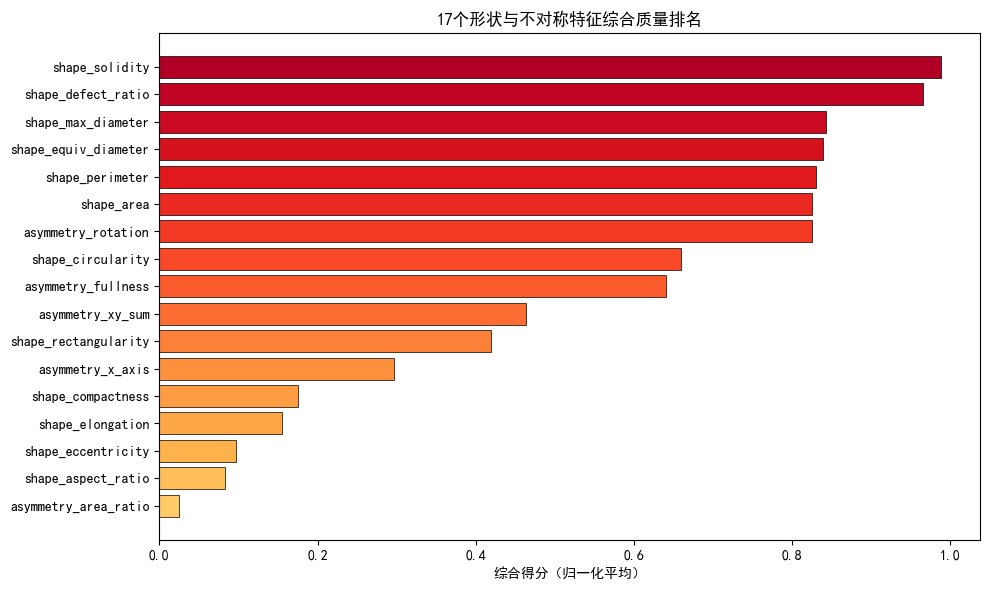

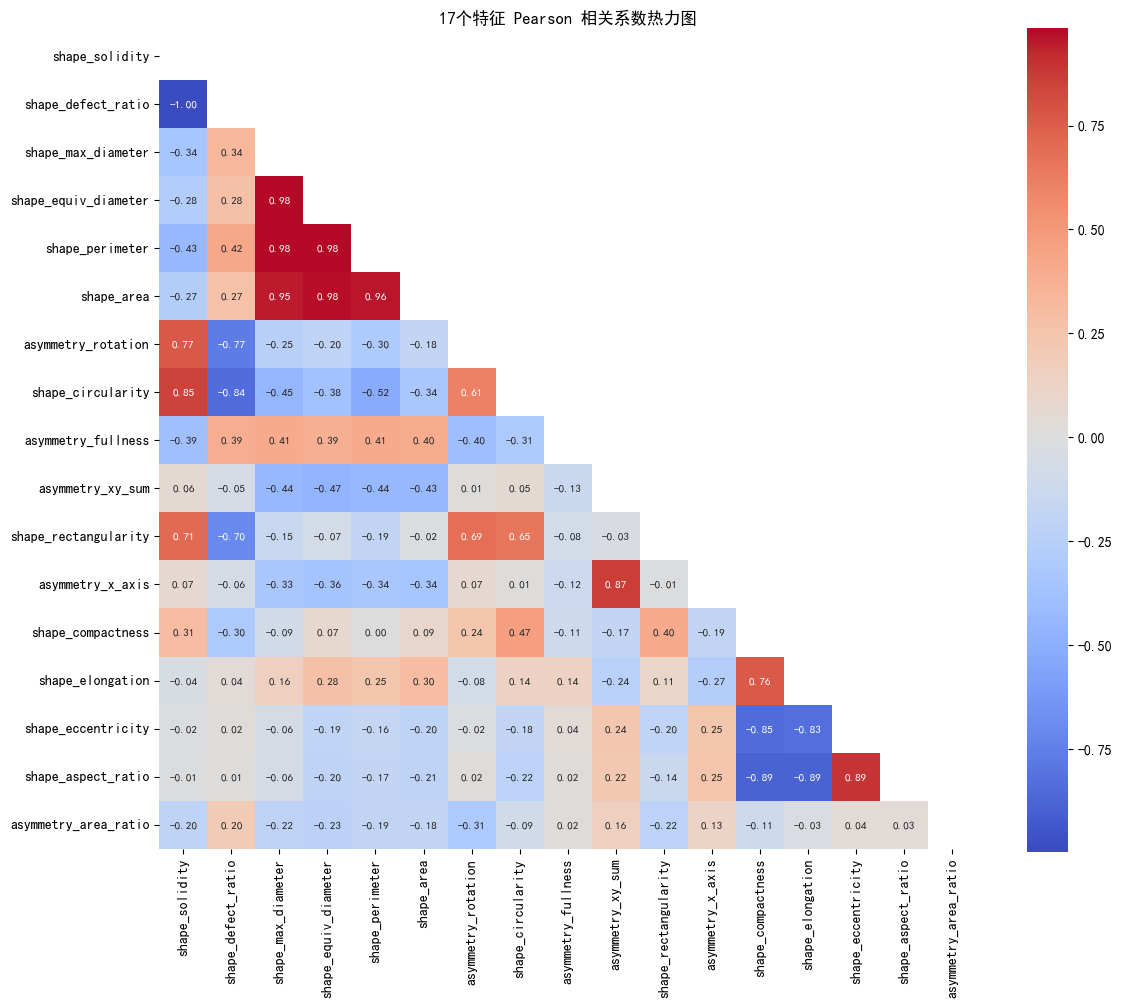

In [54]:
# ==============================================================================
# 3. 可视化：条形图与相关性矩阵分析 
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(df_scores)))
ax.barh(df_scores['feature'][::-1], df_scores['composite_score'][::-1], color=colors, edgecolor='k', linewidth=0.5)
ax.set_xlabel('综合得分（归一化平均）')
ax.set_title('17个形状与不对称特征综合质量排名')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 10))
corr_pearson = df_feat[df_scores['feature'].tolist()].corr(method='pearson')
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))
sns.heatmap(corr_pearson, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, annot_kws={'size': 8})
plt.title('17个特征 Pearson 相关系数热力图')
plt.tight_layout()
plt.show()